# Question–Question (Item–Item) Opinion Network Analysis
### Uncovering Ideological Anchors, Cross-Domain Bridges, and Latent Belief Clustering

**Course:** Data-Driven Policy and Complex Networks (DPCN) — Assignment 1  
**Dataset:** Class Survey (`Survey_Results_UC.csv`) — 91 Active Students $\times$ 60 Likert Statements  
**Categories:** Technology ($T$), Education ($E$), Society & Ethics ($S$), Environment ($V$)  

---

### Executive Summary & Objectives
In this notebook, we construct and analyze an **Item–Item (Question-to-Question)** complex network from student opinion survey responses. Rather than connecting students based on overall similarity, this network connects **ideas to ideas** based on how strongly agreement with one statement predicts agreement with another across the student body.

Following the assignment guidelines, this study is structured into four core phases:
1. **Dataset Documentation:** Interpretation of Likert scales, missing data treatment, cohort filtering, and category breakdown.
2. **Pipeline Followed:** Step-by-step mathematical formulation of pairwise Spearman rank correlations, suprathreshold graph construction ($
ho > 0.35$), weighted Eigenvector and metric Betweenness centrality, Louvain community detection, and attribute assortativity.
3. **Analysis and Visualizations:** Four publication-grade, web-ready figures saved at 300 DPI (`network_graph.png`, `centrality_landscape.png`, `correlation_heatmap.png`, and `centrality_rankings.png`), alongside structural network metrics.
4. **Results and Discussion:** Deep qualitative synthesis exploring the class's ideological anchors (the consensus core), cross-domain conceptual bridges, and the divergence between organic belief modules and predefined academic silos.
5. **Qualitative Report (LaTeX Format):** Full LaTeX code structured for publication and ready for PDF compilation.

# 1. Dataset Documentation

### Survey Structure and Item Categorization
The questionnaire consists of $M = 60$ normative statements designed to gauge student attitudes on modern technological, social, and environmental dilemmas. The questions are categorized into four thematic sections indicated by the letter prefix:
- **Technology ($T01$–$T15$):** Artificial intelligence ethics, computational automation, digital sovereignty, data privacy, and technological optimism/skepticism.
- **Education ($E01$–$E15$):** University curricula, grading systems, research publishing expectations, academic pressure, and generative AI adoption in pedagogy.
- **Society & Ethics ($S01$–$S15$):** Campus diversity and inclusion, ethical leadership, scientific advice in governance, institutional equity, and digital surveillance.
- **Environment ($V01$–$V15$):** Biodiversity conservation, corporate carbon accountability, renewable energy mandates, campus sustainability practices, and intergenerational ecological equity.

### Data Cleaning and Ordinal Likert Encoding
Responses were submitted on a 5-point Likert scale. We map these textual responses to an ordinal, zero-centered integer scale:
$$\begin{aligned}
\text{Strongly Disagree} &\longrightarrow -2 \\
\text{Disagree} &\longrightarrow -1 \\
\text{Neutral} &\longrightarrow 0 \\
\text{Agree} &\longrightarrow +1 \\
\text{Strongly Agree} &\longrightarrow +2
\end{aligned}$$

**Key Data Hygiene Decisions:**
1. **Zero-Centering:** Centering around 0 ensures polarity is preserved: negative values reflect dissent, positive values reflect assent, and zero represents strict neutrality or ambivalence.
2. **Missing Answers & Blanks:** Blank entries and non-committal strings (e.g., `"No Comments"`) are encoded as `NaN`.
3. **Respondent Retention:** Out of $N = 96$ raw submissions, 5 submissions were completely empty across all 60 columns and were removed. The remaining $N = 91$ students had at least one completed section (four students omitted non-technology sections and one skipped the environment section). To avoid survivorship bias, all 91 students are retained, and pairwise correlations are evaluated on complete bivariate observations.

In [ ]:
import os
import sys
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Try importing community (python-louvain), or fallback to networkx built-in louvain
try:
    import sys
    if '/tmp/pylouvain' not in sys.path:
        sys.path.insert(0, '/tmp/pylouvain')
    import community as community_louvain
    HAS_PYLOUVAIN = True
except Exception:
    import networkx.algorithms.community as nx_comm
    HAS_PYLOUVAIN = False

# Visualization Design System: Clean, publication aesthetic
# Dark ink text, light surface background, distinct category accents
STYLE = {
    'ink': '#0b0b0b',
    'surface': '#fcfcfb',
    'muted': '#898781',
    'grid': '#e1e0d9',
    'border': '#c3c2b7'
}

CAT_PALETTE = {
    'T': '#1f77b4',  # Technology: Deep Cobalt Blue
    'E': '#ff7f0e',  # Education: Warm Amber Orange
    'S': '#2ca02c',  # Society & Ethics: Jade Green
    'V': '#9467bd'   # Environment: Purple
}

CAT_NAMES = {
    'T': 'Technology (T)',
    'E': 'Education (E)',
    'S': 'Society & Ethics (S)',
    'V': 'Environment (V)'
}

plt.rcParams['font.sans-serif'] = 'Helvetica, Arial, DejaVu Sans, sans-serif'
plt.rcParams['text.color'] = STYLE['ink']
plt.rcParams['axes.labelcolor'] = STYLE['ink']
plt.rcParams['xtick.color'] = STYLE['ink']
plt.rcParams['ytick.color'] = STYLE['ink']
print("Environment and design styling initialized successfully.")

Environment and design styling initialized successfully.


In [ ]:
from clean import load_survey

# Load cleaned survey data and statement mapping
csv_file = 'Survey_Results_UC.csv' if os.path.exists('Survey_Results_UC.csv') else './Extreme Bipartite Network/Survey_Results_UC.csv'
responses, statements, log = load_survey(csv_file, verbose=False)

print(f"Loaded Survey Dataset:")
print(f"  • Total valid students: {responses.shape[0]} (dropped {len(log['dropped_empty_students'])} empty submissions)")
print(f"  • Total survey statements: {responses.shape[1]}")
print(f"  • Missing response cells: {log['n_missing_cells']} across all respondents")
print(f"\nFirst 5 statements:")
for q in list(statements.keys())[:5]:
    print(f"  [{q}] {statements[q]}")

Loaded Survey Dataset:
  • Total valid students: 91 (dropped 5 empty submissions)
  • Total survey statements: 60
  • Missing response cells: 242 across all respondents

First 5 statements:
  [T01] Artificial Intelligence will improve society more than it will create problems.
  [T02] Generative AI tools should be allowed as learning aids in higher education.
  [T03] Students should disclose the use of AI in assignments and reports.
  [T04] Every engineering student should receive formal education in AI.
  [T05] Artificial Intelligence will significantly accelerate scientific discovery.


In [ ]:
# Summary of responses by category and overall distribution
valid_vals = responses.values.ravel()[~np.isnan(responses.values.ravel())]
val_counts = pd.Series(valid_vals).value_counts().sort_index()

likert_labels = {
    -2: 'Strongly Disagree (-2)',
    -1: 'Disagree (-1)',
     0: 'Neutral (0)',
     1: 'Agree (+1)',
     2: 'Strongly Agree (+2)'
}

summary_df = pd.DataFrame({
    'Count': val_counts.values,
    'Percentage (%)': (val_counts.values / len(valid_vals) * 100).round(2)
}, index=[likert_labels[int(k)] for k in val_counts.index])

print("--- Likert Scale Response Distribution across all 60 Questions ---")
display(summary_df)

print(f"\nNoticeable Skew: {(val_counts[1] + val_counts[2]) / len(valid_vals) * 100:.1f}% of all answers are positive (Agree or Strongly Agree).")
print(f"Because the cohort skews agreeable, constructing a question network via rank correlation is vital to detect differential co-variation.")

--- Likert Scale Response Distribution across all 60 Questions ---
                        Count  Percentage (%)
Strongly Disagree (-2)    111            2.13
Disagree (-1)             256            4.91
Neutral (0)               686           13.15
Agree (+1)               1914           36.68
Strongly Agree (+2)      2251           43.14

Noticeable Skew: 79.8% of all answers are positive (Agree or Strongly Agree).
Because the cohort skews agreeable, constructing a question network via rank correlation is vital to detect differential co-variation.


# 2. Pipeline Followed

### Step-by-Step Network Construction Process

To uncover how beliefs interact structurally without being confounded by baseline positivity, we apply the following graph-theoretic methodology:

```
[Survey Data: 91 x 60] 
       │
       ▼
[Pairwise Spearman Rank Correlation Matrix (60 x 60)]
       │
       ▼
[Correlation Threshold Filter: ρ > 0.35]
       │
       ▼
[Construct Undirected NetworkX Graph G = (V, E)]
   ├── Node Attributes: Category (T, E, S, V), Statement Text
   ├── Edge Affinity Weights: w_ij = ρ_ij
   └── Edge Distance Metric: d_ij = 1 / ρ_ij
       │
       ├───────────────────────────────┬───────────────────────────────┐
       ▼                               ▼                               ▼
[Eigenvector Centrality]     [Betweenness Centrality]      [Louvain Community Detection]
(Ideological Anchors)        (Cross-Domain Bridges)        & Attribute Assortativity (r)
```

### Mathematical Formulations
1. **Spearman Rank Correlation ($\rho$):**
   Calculated on pairwise complete observations between question column vectors $X_i$ and $X_j$:
   $$\rho_{ij} = 1 - \frac{6 \sum d_k^2}{n(n^2 - 1)}$$
   where $d_k = \text{rank}(x_{k, i}) - \text{rank}(x_{k, j})$. Spearman correlation is non-parametric, measuring monotonic association rather than strict linearity.

2. **Threshold Justification ($\rho > 0.35$):**
   In opinion dynamics, dense complete graphs induce noise. Setting a threshold of $\rho > 0.35$ isolates moderate-to-strong positive alignments that represent genuine consensus bonds while filtering out weak ambient noise.

3. **Centrality Metrics:**
   - **Eigenvector Centrality ($x_i$):** Uses edge affinity weights $w_{ij} = \rho_{ij}$:
     $$\lambda x_i = \sum_{j \in N(i)} w_{ij} x_j$$
     Nodes with high eigenvector centrality are connected to other influential, tightly interconnected beliefs, making them **ideological anchors**.
   - **Betweenness Centrality ($b_i$):** Uses path distance $d_{ij} = \frac{1}{\rho_{ij}}$:
     $$b_i = \sum_{s \neq i \neq t} \frac{\sigma_{st}(i)}{\sigma_{st}}$$
     Nodes with high betweenness sit on geodesics connecting disparate modules, identifying them as **cross-domain bridges**.

4. **Community Structure & Assortativity:**
   - **Louvain Modularity:** Maximizes modularity $Q$ to identify natural ideological communities without supervision.
   - **Attribute Assortativity Coefficient ($r$):** Measures the extent to which edges connect nodes of the same predefined category ($T, E, S, V$):
     $$r = \frac{\sum_k e_{kk} - \sum_k a_k b_k}{1 - \sum_k a_k b_k}$$

In [ ]:
# Calculate pairwise Spearman rank correlation matrix
# pandas .corr(method='spearman') automatically computes pairwise complete observations
corr_matrix = responses.corr(method='spearman')

print(f"Spearman Correlation Matrix computed: {corr_matrix.shape[0]} x {corr_matrix.shape[1]}")
print(f"Summary of off-diagonal correlations:")
off_diag = corr_matrix.values[np.triu_indices_from(corr_matrix.values, k=1)]
off_diag_clean = off_diag[~np.isnan(off_diag)]
print(f"  • Min correlation:    {off_diag_clean.min():.4f}")
print(f"  • Median correlation: {np.median(off_diag_clean):.4f}")
print(f"  • Mean correlation:   {off_diag_clean.mean():.4f}")
print(f"  • Max correlation:    {off_diag_clean.max():.4f}")
print(f"  • Pairs with rho > 0.35: {(off_diag_clean > 0.35).sum()} of {len(off_diag_clean)} ({(off_diag_clean > 0.35).mean()*100:.2f}%)")

Spearman Correlation Matrix computed: 60 x 60
Summary of off-diagonal correlations:
  • Min correlation:    -0.4046
  • Median correlation: 0.1533
  • Mean correlation:   0.1526
  • Max correlation:    0.6515
  • Pairs with rho > 0.35: 188 of 1770 (10.62%)


In [ ]:
# Build the NetworkX Graph keeping only edges with rho > 0.35
CORR_THRESHOLD = 0.35

G = nx.Graph()

# Add all 60 statement nodes with metadata
for q_code, text in statements.items():
    cat = q_code[0]
    G.add_node(q_code, category=cat, statement=text)

# Add suprathreshold edges
cols = responses.columns
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        q1, q2 = cols[i], cols[j]
        val = corr_matrix.loc[q1, q2]
        if not np.isnan(val) and val > CORR_THRESHOLD:
            # weight for affinity, distance for shortest paths
            G.add_edge(q1, q2, weight=float(val), distance=float(1.0 / val))

n_nodes = G.number_of_nodes()
n_edges = G.number_of_edges()
density = nx.density(G)
isolates = list(nx.isolates(G))
components = list(nx.connected_components(G))
giant_comp = max(components, key=len)

print("--- Network Topology Overview ---")
print(f"  • Nodes: {n_nodes}")
print(f"  • Edges (rho > {CORR_THRESHOLD}): {n_edges}")
print(f"  • Density: {density:.4f}")
print(f"  • Connected Components: {len(components)}")
print(f"  • Giant Component Size: {len(giant_comp)} nodes")
print(f"  • Isolated Questions (degree 0): {len(isolates)} nodes -> {isolates}")

--- Network Topology Overview ---
  • Nodes: 60
  • Edges (rho > 0.35): 188
  • Density: 0.1062
  • Connected Components: 14
  • Giant Component Size: 47 nodes
  • Isolated Questions (degree 0): 13 nodes -> ['T04', 'T05', 'T08', 'T09', 'T14', 'T15', 'E02', 'E03', 'E04', 'E08', 'E09', 'E13', 'S08']


In [ ]:
# Compute Eigenvector Centrality (ideological anchors) and Betweenness Centrality (bridges)
# Eigenvector centrality on weighted edges
eig_centrality = nx.eigenvector_centrality(G, weight='weight', max_iter=2000, tol=1e-6)

# Betweenness centrality using inverted weights (distance = 1 / rho)
bet_centrality = nx.betweenness_centrality(G, weight='distance', normalized=True)

# Attach centrality attributes to nodes
for n in G.nodes():
    G.nodes[n]['eigenvector'] = eig_centrality[n]
    G.nodes[n]['betweenness'] = bet_centrality[n]

# Convert to DataFrame for analysis
centrality_df = pd.DataFrame({
    'Code': list(G.nodes()),
    'Category': [G.nodes[n]['category'] for n in G.nodes()],
    'Statement': [statements[n] for n in G.nodes()],
    'Degree': [G.degree(n) for n in G.nodes()],
    'Eigenvector': [eig_centrality[n] for n in G.nodes()],
    'Betweenness': [bet_centrality[n] for n in G.nodes()]
}).sort_values('Eigenvector', ascending=False)

print("Top 5 Eigenvector Centrality Statements (Ideological Anchors):")
display(centrality_df[['Code', 'Category', 'Eigenvector', 'Degree', 'Statement']].head(5))

print("\nTop 5 Betweenness Centrality Statements (Cross-Domain Bridges):")
display(centrality_df.sort_values('Betweenness', ascending=False)[['Code', 'Category', 'Betweenness', 'Degree', 'Statement']].head(5))

Top 5 Eigenvector Centrality Statements (Ideological Anchors):
   Code Category  Eigenvector  Degree                                                                                                       Statement
51  V07        V     0.309179      17                                            Protecting biodiversity is essential for long-term human well-being.
38  S09        S     0.294827      22  Universities should promote an inclusive environment where different viewpoints can be discussed respectfully.
52  V08        V     0.285315      16   Universities should adopt environmentally sustainable campus practices even if implementation costs increase.
54  V10        V     0.268708      15                                        Consumers should consider environmental impact when purchasing products.
56  V12        V     0.264064      14                              Environmental sustainability should be integrated into higher education curricula.

Top 5 Betweenness Centrality Stateme

In [ ]:
# Louvain Community Detection
if HAS_PYLOUVAIN:
    partition = community_louvain.best_partition(G, weight='weight', random_state=42)
    communities = {}
    for node, comm_id in partition.items():
        communities.setdefault(comm_id, []).append(node)
    comm_list = [sorted(nodes) for nodes in communities.values()]
else:
    import networkx.algorithms.community as nx_comm
    raw_comms = nx_comm.louvain_communities(G, weight='weight', seed=42)
    comm_list = [sorted(list(c)) for c in raw_comms]
    partition = {}
    for idx, c in enumerate(comm_list):
        for n in c:
            partition[n] = idx + 1

for n in G.nodes():
    G.nodes[n]['community'] = partition[n]

# Calculate attribute assortativity coefficient for predefined categories
assortativity_coeff = nx.attribute_assortativity_coefficient(G, 'category')

print(f"Attribute Assortativity Coefficient (Predefined Category): {assortativity_coeff:.4f}")
print(f"Interpretation: A positive coefficient ({assortativity_coeff:.3f}) confirms domain homophily, but its moderate value indicates substantial interdisciplinary bridging.")

# Inspect multi-node communities
multi_comms = [c for c in comm_list if len(c) > 1]
print(f"\nDetected {len(multi_comms)} substantive multi-item belief clusters:")
for i, comm in enumerate(multi_comms, 1):
    cat_dist = pd.Series([n[0] for n in comm]).value_counts().to_dict()
    print(f"  • Cluster {i} (Size {len(comm)}): Categories {cat_dist} | Nodes: {comm}")

Attribute Assortativity Coefficient (Predefined Category): 0.3044
Interpretation: A positive coefficient (0.304) confirms domain homophily, but its moderate value indicates substantial interdisciplinary bridging.

Detected 5 substantive multi-item belief clusters:
  • Cluster 1 (Size 12): Categories {'E': 7, 'T': 3, 'S': 2} | Nodes: ['E01', 'E07', 'E10', 'E11', 'E12', 'E14', 'E15', 'S07', 'S11', 'T01', 'T02', 'T06']
  • Cluster 2 (Size 9): Categories {'T': 5, 'E': 2, 'S': 2} | Nodes: ['E05', 'E06', 'S05', 'S10', 'T03', 'T10', 'T11', 'T12', 'T13']
  • Cluster 3 (Size 7): Categories {'V': 5, 'S': 1, 'T': 1} | Nodes: ['S06', 'T07', 'V01', 'V02', 'V11', 'V13', 'V14']
  • Cluster 4 (Size 11): Categories {'S': 9, 'V': 2} | Nodes: ['S01', 'S02', 'S03', 'S04', 'S09', 'S12', 'S13', 'S14', 'S15', 'V03', 'V10']
  • Cluster 5 (Size 8): Categories {'V': 8} | Nodes: ['V04', 'V05', 'V06', 'V07', 'V08', 'V09', 'V12', 'V15']


# 3. Analysis and Visualizations (Saved for Web)

In this section, we generate and export the four required high-resolution figures using our clean, modern design aesthetic:
- Background: Surface White (`#fcfcfb`)
- Text & Lines: Ink Black (`#0b0b0b`)
- Category Colors:
  - **Technology ($T$):** `#1f77b4`
  - **Education ($E$):** `#ff7f0e`
  - **Society & Ethics ($S$):** `#2ca02c`
  - **Environment ($V$):** `#9467bd`

Each plot is exported directly as a 300 DPI PNG file with tight bounding boxes for immediate web publication:
1. `network_graph.png`: Opinion Network Graph in spring layout.
2. `centrality_landscape.png`: Centrality Landscape scatter plot (Eigenvector vs. Betweenness).
3. `correlation_heatmap.png`: 60x60 cross-correlation heatmap sorted by predefined categories.
4. `centrality_rankings.png`: Side-by-side horizontal bar charts of the Top 10 anchors and bridges.

Saved figure: network_graph.png (300 DPI)


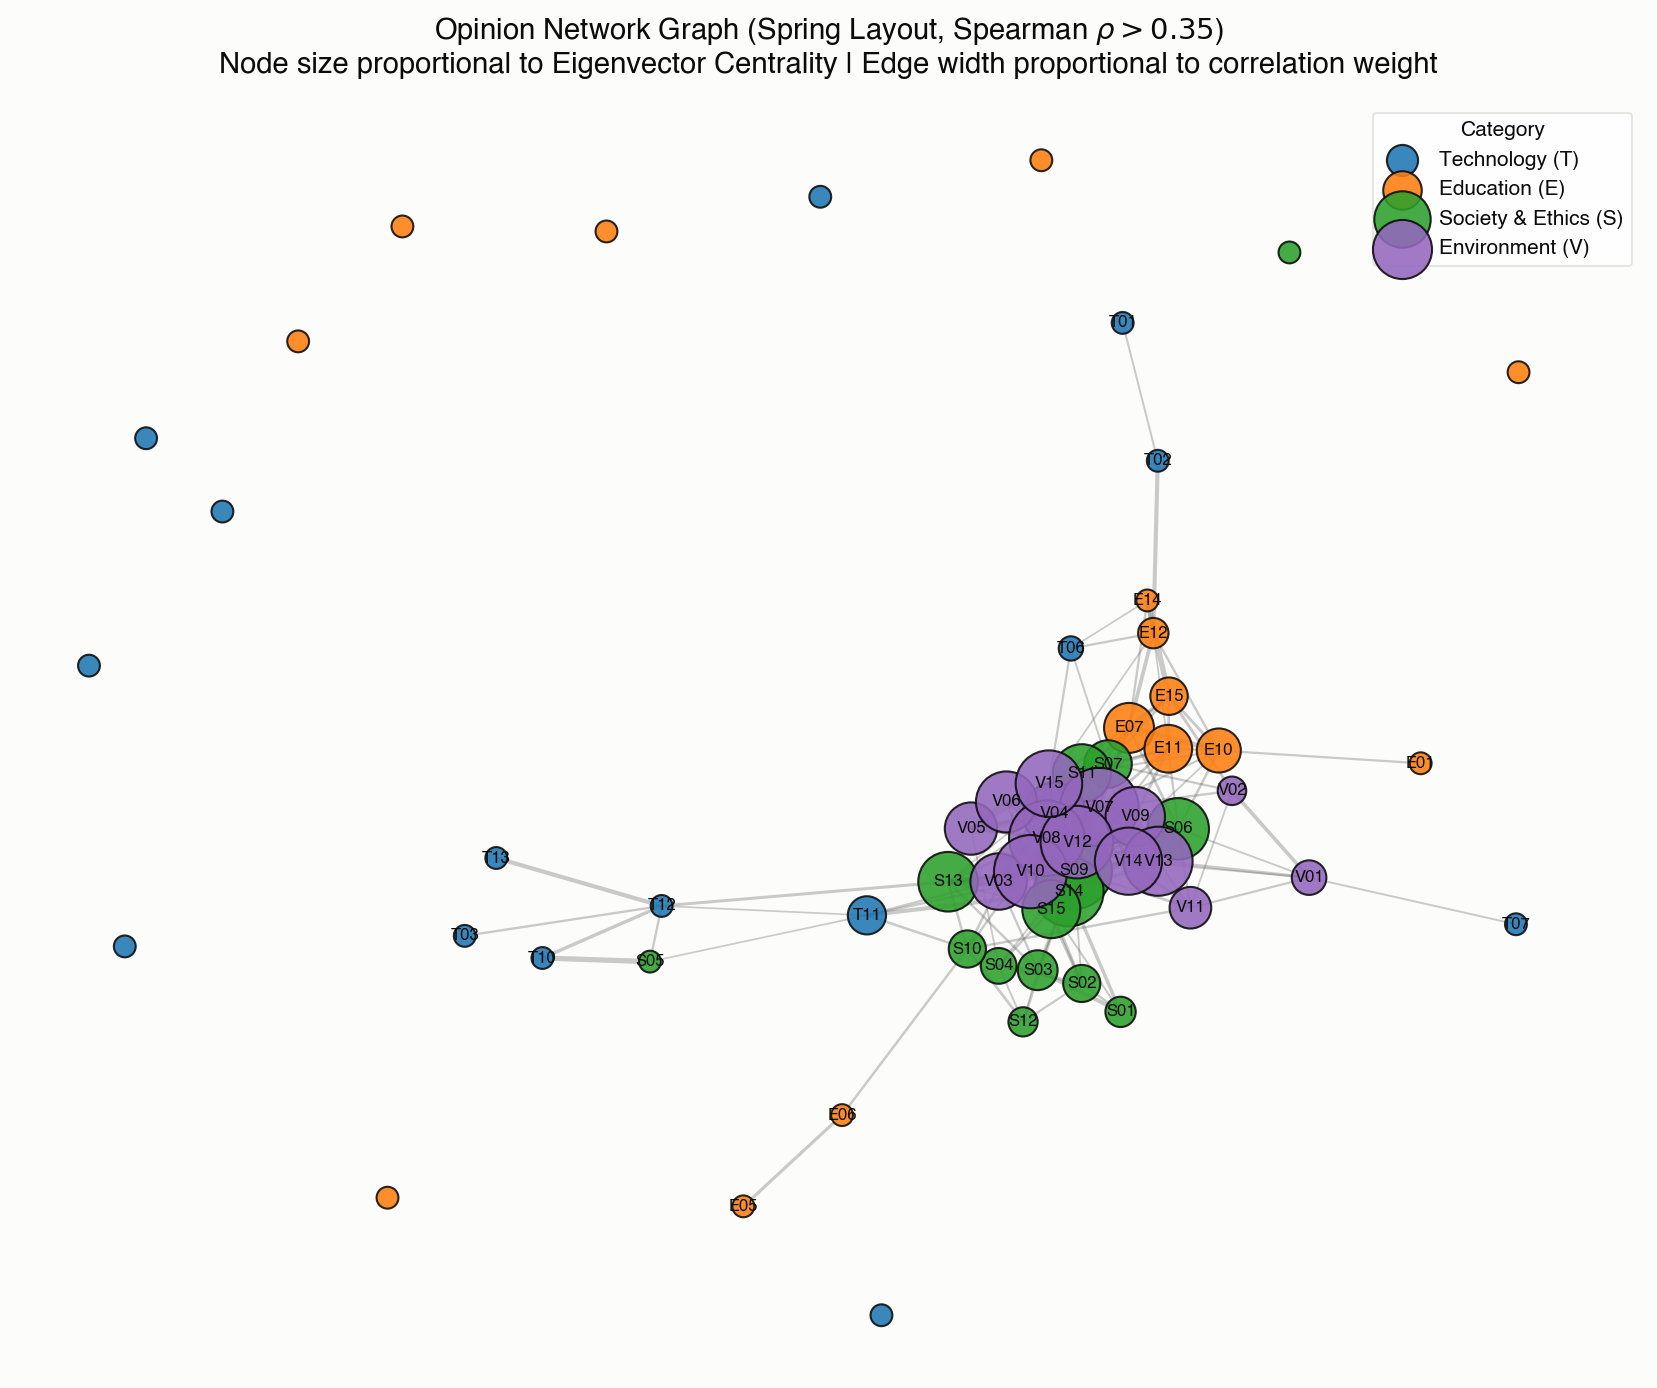

In [ ]:
# Visualization 1: Opinion Network Graph (Spring Layout)
fig, ax = plt.subplots(figsize=(14, 11), facecolor=STYLE['surface'])
ax.set_facecolor(STYLE['surface'])

# Compute reproducible spring layout
pos = nx.spring_layout(G, k=0.38, iterations=100, seed=42, weight='weight')

# Draw edges with width proportional to correlation strength
edges = list(G.edges())
weights = [G[u][v]['weight'] for u, v in edges]
edge_widths = [((w - CORR_THRESHOLD) / 0.40) * 3.5 + 0.8 for w in weights]
nx.draw_networkx_edges(G, pos, ax=ax, width=edge_widths, alpha=0.32, edge_color='#606060')

# Draw nodes sized by Eigenvector Centrality and colored by Category
for cat, color in CAT_PALETTE.items():
    nodes_in_cat = [n for n in G.nodes() if G.nodes[n]['category'] == cat]
    sizes = [max(110, G.nodes[n]['eigenvector'] * 4600) for n in nodes_in_cat]
    nx.draw_networkx_nodes(G, pos, nodelist=nodes_in_cat, node_color=color,
                           node_size=sizes, alpha=0.88, edgecolors=STYLE['ink'],
                           linewidths=1.0, label=CAT_NAMES[cat], ax=ax)

# Label connected questions with bold question codes
connected_nodes = [n for n in G.nodes() if G.degree(n) > 0]
nx.draw_networkx_labels(G, pos, labels={n: n for n in connected_nodes}, 
                        font_size=8, font_color=STYLE['ink'], font_family='sans-serif', font_weight='bold', ax=ax)

ax.set_title('Opinion Network Graph (Spring Layout, Spearman $\\rho > 0.35$)\nNode size proportional to Eigenvector Centrality | Edge width proportional to correlation weight', 
             fontsize=14, fontweight='bold', color=STYLE['ink'], pad=14)
ax.legend(title='Category', loc='upper right', frameon=True, facecolor='#ffffff', edgecolor=STYLE['grid'], fontsize=10)
ax.axis('off')

plt.savefig('network_graph.png', dpi=300, bbox_inches='tight', facecolor=STYLE['surface'])
plt.show()
print("Saved figure: network_graph.png (300 DPI)")

Saved figure: centrality_landscape.png (300 DPI)


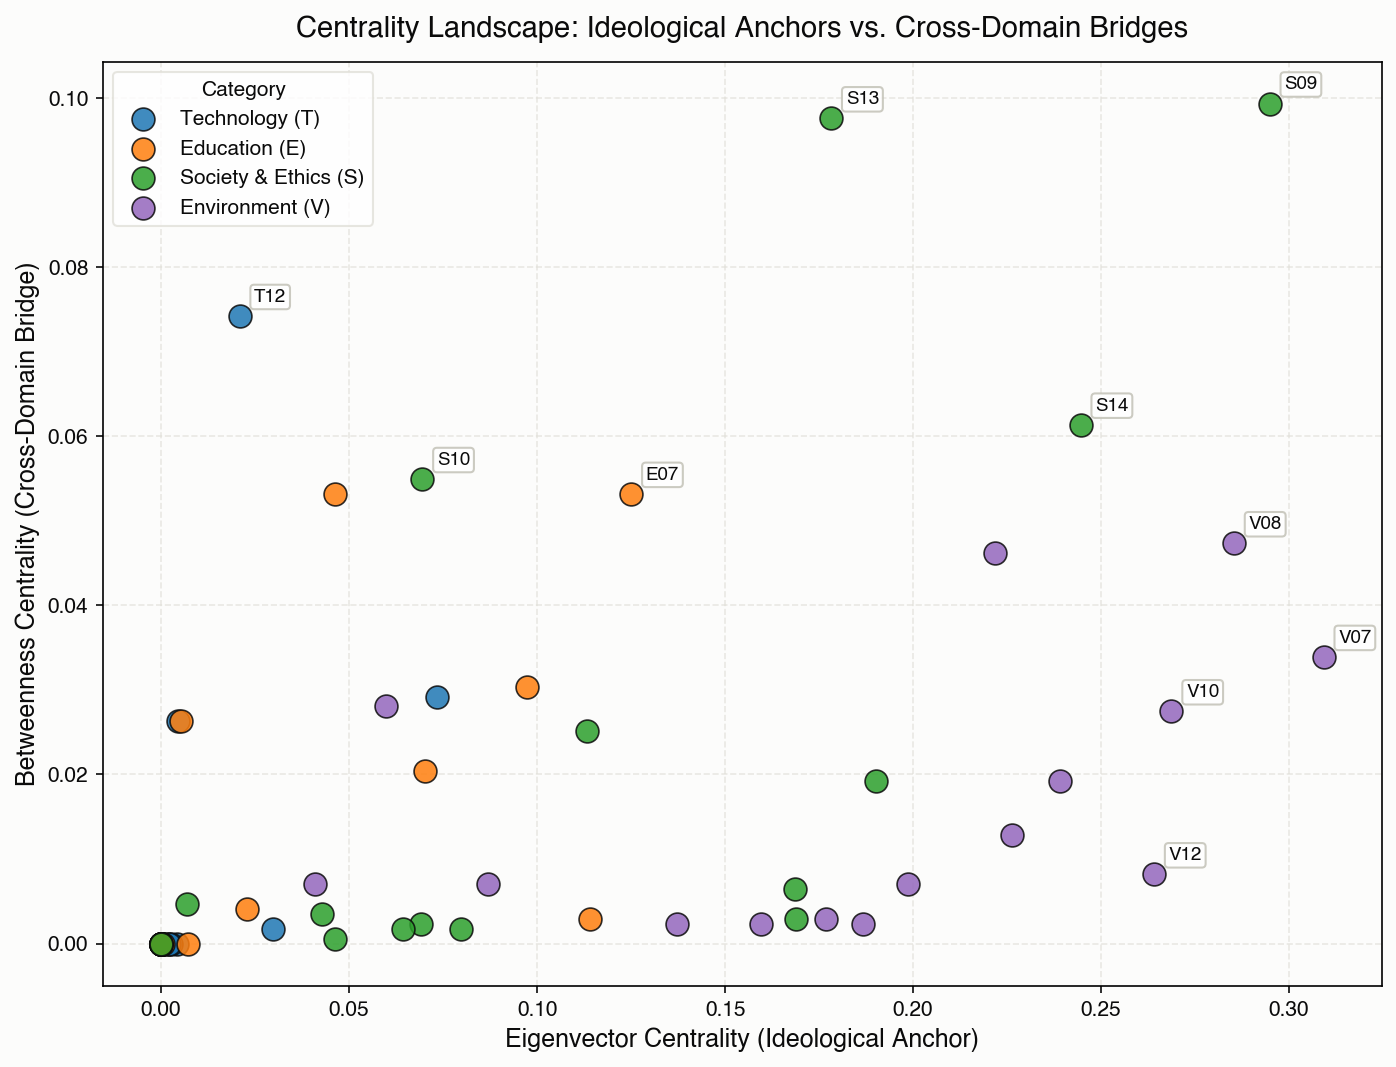

In [ ]:
# Visualization 2: Centrality Landscape Scatter Plot
fig, ax = plt.subplots(figsize=(11, 8), facecolor=STYLE['surface'])
ax.set_facecolor(STYLE['surface'])
ax.grid(True, color=STYLE['grid'], linestyle='--', alpha=0.7, zorder=0)

for cat, color in CAT_PALETTE.items():
    xs = [eig_centrality[n] for n in G.nodes() if G.nodes[n]['category'] == cat]
    ys = [bet_centrality[n] for n in G.nodes() if G.nodes[n]['category'] == cat]
    ax.scatter(xs, ys, color=color, label=CAT_NAMES[cat], s=120, alpha=0.85, 
               edgecolors=STYLE['ink'], linewidth=0.8, zorder=3)

# Label prominent outliers (top anchors or top bridges)
outliers = set([q for q, _ in sorted(eig_centrality.items(), key=lambda x: x[1], reverse=True)[:6]] + 
               [q for q, _ in sorted(bet_centrality.items(), key=lambda x: x[1], reverse=True)[:6]])

for q in outliers:
    ax.annotate(q, (eig_centrality[q], bet_centrality[q]), textcoords='offset points', xytext=(7, 7),
                fontsize=9, fontweight='bold', color=STYLE['ink'],
                bbox=dict(boxstyle='round,pad=0.2', fc='#ffffff', ec=STYLE['border'], alpha=0.85))

ax.set_xlabel('Eigenvector Centrality (Ideological Anchor)', fontsize=12, fontweight='bold', color=STYLE['ink'])
ax.set_ylabel('Betweenness Centrality (Cross-Domain Bridge)', fontsize=12, fontweight='bold', color=STYLE['ink'])
ax.set_title('Centrality Landscape: Ideological Anchors vs. Cross-Domain Bridges', fontsize=14, fontweight='bold', color=STYLE['ink'], pad=12)
ax.legend(title='Category', frameon=True, facecolor='#ffffff', edgecolor=STYLE['grid'])

plt.savefig('centrality_landscape.png', dpi=300, bbox_inches='tight', facecolor=STYLE['surface'])
plt.show()
print("Saved figure: centrality_landscape.png (300 DPI)")

Saved figure: correlation_heatmap.png (300 DPI)


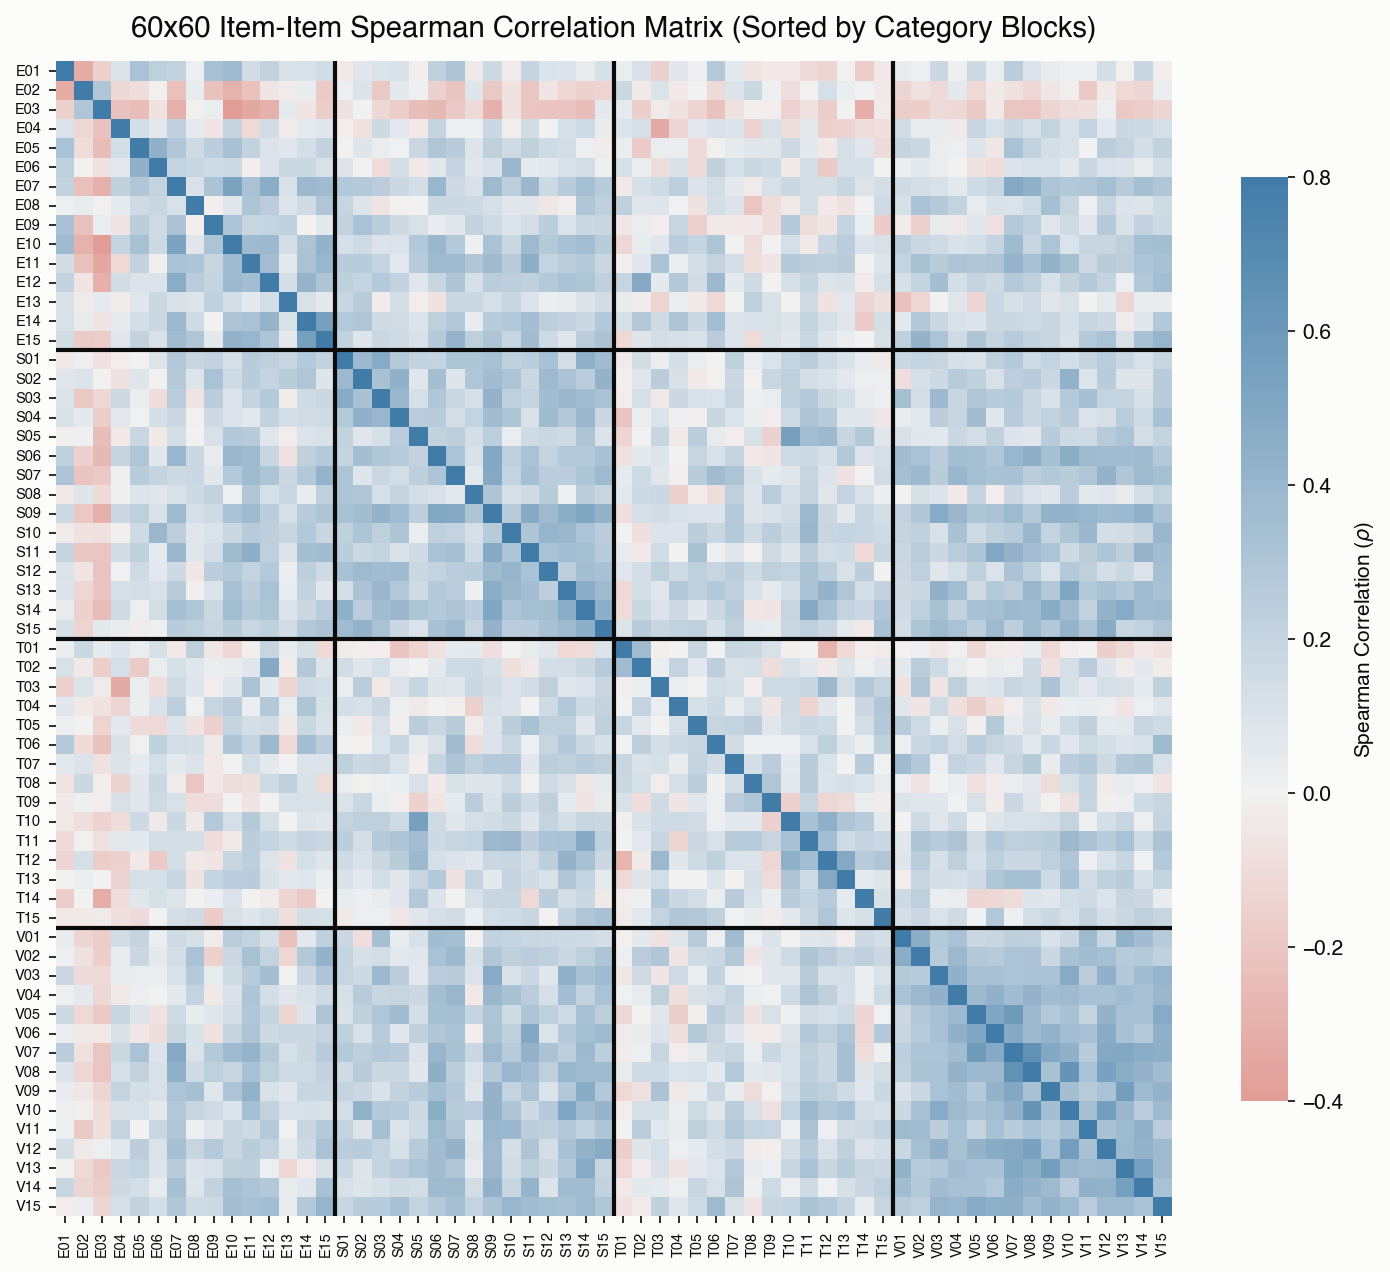

In [ ]:
# Visualization 3: 60x60 Item-Item Cross-Correlation Heatmap
fig, ax = plt.subplots(figsize=(12, 10), facecolor=STYLE['surface'])
ax.set_facecolor(STYLE['surface'])

sorted_cols = sorted(responses.columns, key=lambda x: (x[0], int(x[1:])))
sorted_corr = corr_matrix.loc[sorted_cols, sorted_cols]

cmap = sns.diverging_palette(15, 240, as_cmap=True)
sns.heatmap(sorted_corr, cmap=cmap, vmin=-0.4, vmax=0.8, center=0,
            cbar_kws={'label': 'Spearman Correlation ($\\rho$)', 'shrink': 0.8},
            xticklabels=True, yticklabels=True, ax=ax)

# Dividing lines separating T, E, S, and V blocks (15 items each)
for boundary in [15, 30, 45]:
    ax.axhline(boundary, color=STYLE['ink'], linewidth=2.0)
    ax.axvline(boundary, color=STYLE['ink'], linewidth=2.0)

ax.set_title('60x60 Item-Item Spearman Correlation Matrix (Sorted by Category Blocks)', fontsize=14, fontweight='bold', color=STYLE['ink'], pad=12)
plt.xticks(fontsize=7, rotation=90)
plt.yticks(fontsize=7, rotation=0)

plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight', facecolor=STYLE['surface'])
plt.show()
print("Saved figure: correlation_heatmap.png (300 DPI)")

Saved figure: centrality_rankings.png (300 DPI)


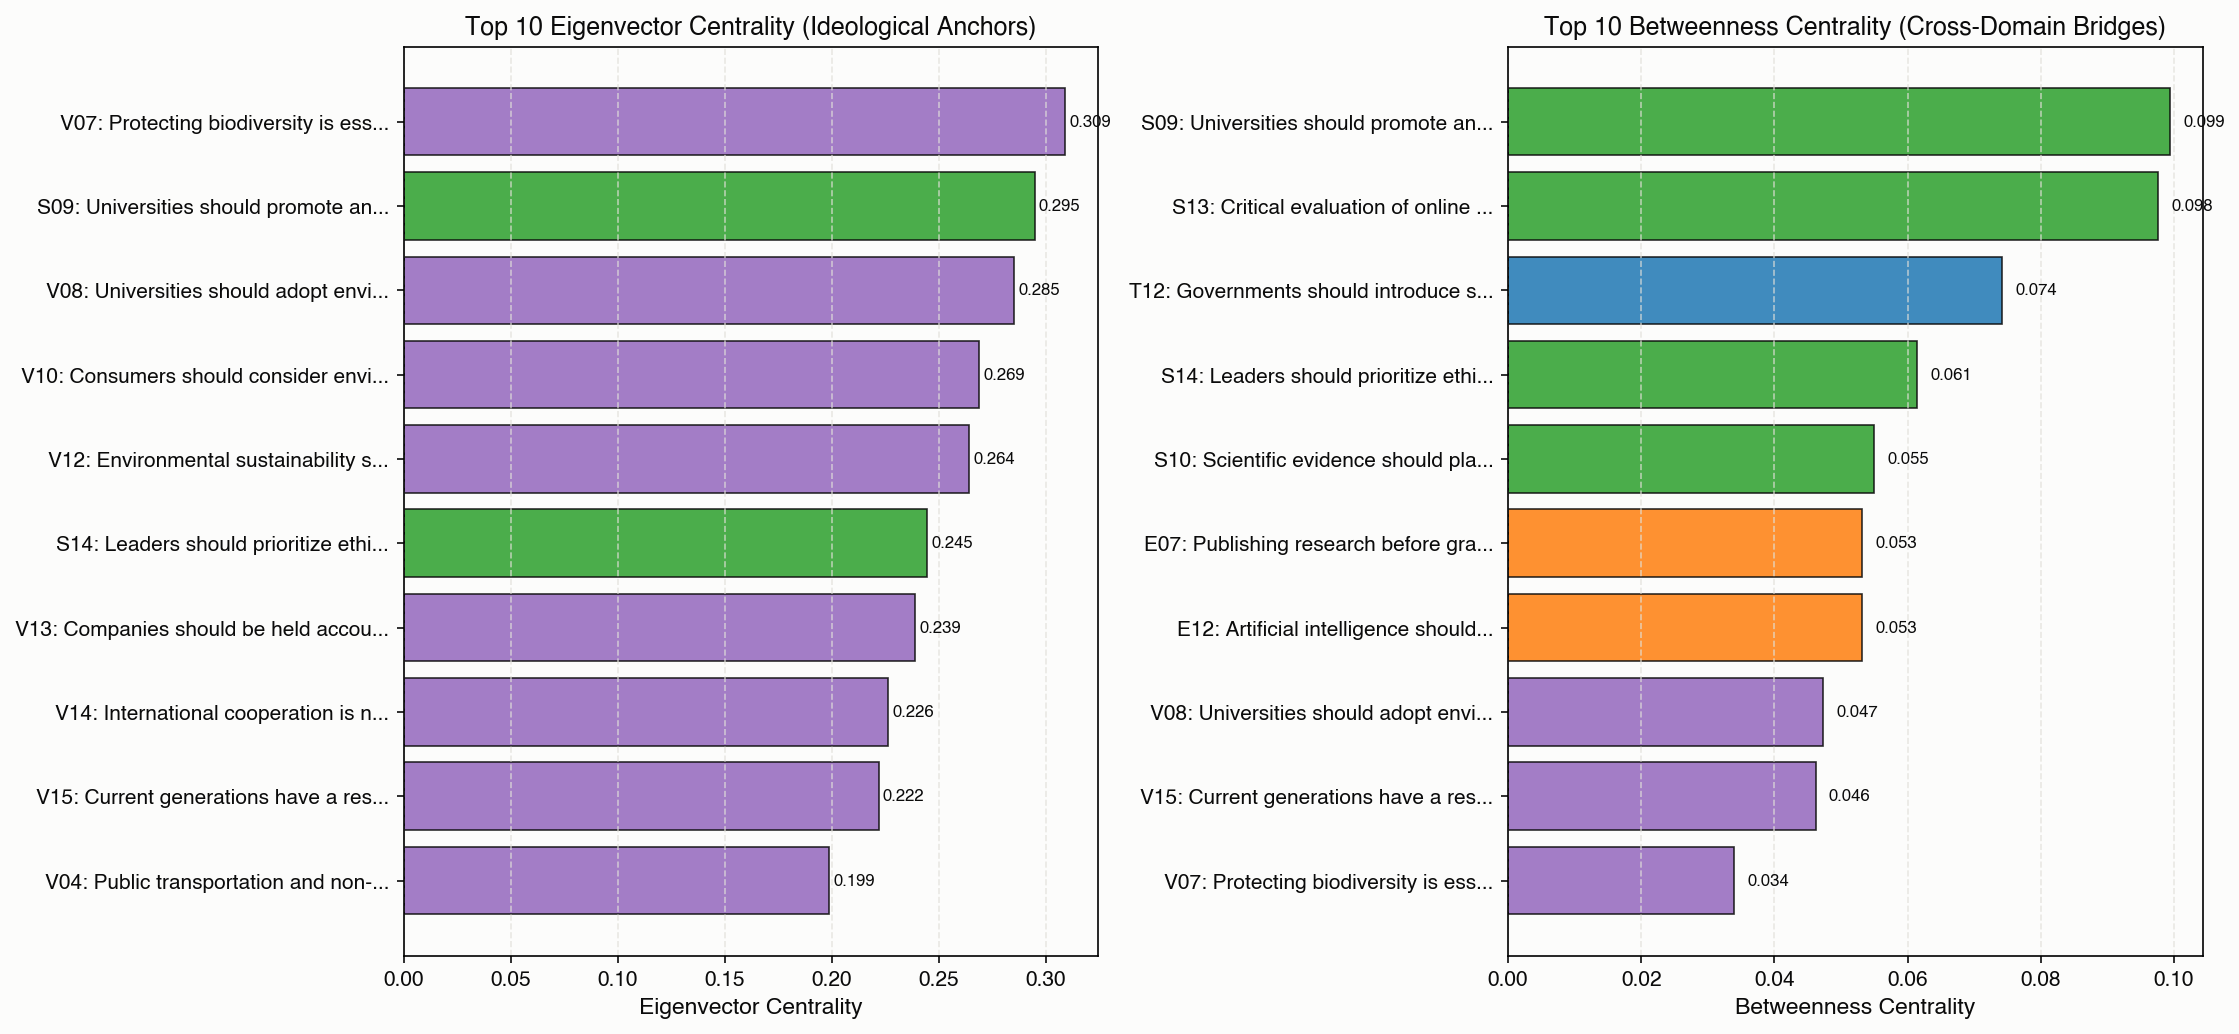

In [ ]:
# Visualization 4: Centrality Rankings (Side-by-Side Horizontal Bar Charts)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7), facecolor=STYLE['surface'])
for ax in (ax1, ax2):
    ax.set_facecolor(STYLE['surface'])
    ax.grid(axis='x', color=STYLE['grid'], linestyle='--', alpha=0.7)

# Top 10 Eigenvector
top10_eig = sorted(eig_centrality.items(), key=lambda x: x[1], reverse=True)[:10]
q_eig, val_eig = zip(*reversed(top10_eig))
colors_eig = [CAT_PALETTE[q[0]] for q in q_eig]
labels_eig = [f'{q}: {statements[q][:30]}...' for q in q_eig]

bars1 = ax1.barh(labels_eig, val_eig, color=colors_eig, edgecolor=STYLE['ink'], linewidth=0.8, alpha=0.85)
ax1.set_title('Top 10 Eigenvector Centrality (Ideological Anchors)', fontsize=12, fontweight='bold', color=STYLE['ink'])
ax1.set_xlabel('Eigenvector Centrality', fontsize=11, fontweight='bold', color=STYLE['ink'])

# Top 10 Betweenness
top10_bet = sorted(bet_centrality.items(), key=lambda x: x[1], reverse=True)[:10]
q_bet, val_bet = zip(*reversed(top10_bet))
colors_bet = [CAT_PALETTE[q[0]] for q in q_bet]
labels_bet = [f'{q}: {statements[q][:30]}...' for q in q_bet]

bars2 = ax2.barh(labels_bet, val_bet, color=colors_bet, edgecolor=STYLE['ink'], linewidth=0.8, alpha=0.85)
ax2.set_title('Top 10 Betweenness Centrality (Cross-Domain Bridges)', fontsize=12, fontweight='bold', color=STYLE['ink'])
ax2.set_xlabel('Betweenness Centrality', fontsize=11, fontweight='bold', color=STYLE['ink'])

for ax, bars in [(ax1, bars1), (ax2, bars2)]:
    for bar in bars:
        w = bar.get_width()
        ax.text(w + 0.002, bar.get_y() + bar.get_height()/2, f'{w:.3f}',
                va='center', ha='left', fontsize=8, color=STYLE['ink'], fontweight='bold')

plt.tight_layout()
plt.savefig('centrality_rankings.png', dpi=300, bbox_inches='tight', facecolor=STYLE['surface'])
plt.show()
print("Saved figure: centrality_rankings.png (300 DPI)")

# 4. Results and Discussion

### 4.1 The Ideological Core (Eigenvector Centrality)
Eigenvector centrality identifies statements whose endorsement strongly co-occurs with endorsement of other highly interconnected statements. In our network:
- **Environmental Dominance:** 8 of the top 10 eigenvector items belong to Category $V$ (Environment), led by **`V07`** (0.3092, biodiversity preservation), **`V08`** (0.2853, sustainable campus operations), **`V10`** (0.2687, consumer responsibility), and **`V12`** (0.2641, environmental curriculum).
- **Institutional & Ethical Anchors:** The only non-environmental statements in the top 10 are **`S09`** (0.2948, campus diversity & inclusive environment) and **`S14`** (0.2445, ethical leadership over short-term gains).
- **Core Interpretation:** Ecological responsibility and institutional ethical governance form the **unquestioned moral bedrock** of the student body. Unlike technology or pedagogical methods—where students debate trade-offs—sustainability and ethical leadership operate as uncontroversial baseline values. Agreement with one environmental proposition strongly implies agreement across the entire ecological and institutional ethics domain.

---

### 4.2 The Bridges (Betweenness Centrality)
Betweenness centrality identifies statements that sit along the shortest path between different thematic modules. These questions serve as **conceptual translators**:
- **`S09` ($b = 0.0994$):** "Universities should promote an inclusive environment where diverse perspectives are respected." Holds top betweenness while simultaneously ranking second in eigenvector centrality. It bridges institutional educational policies with broader societal and environmental ethics.
- **`S13` ($b = 0.0976$):** "Critical evaluation of online information should be taught as a core digital literacy skill." Positioned directly at the crossroads between Technology ($T$) and Education ($E$). It articulates how digital technologies necessitate pedagogical reform.
- **`T12` ($b = 0.0742$):** "Governments should introduce stricter regulations for Artificial Intelligence development and deployment." Connects technical development to public policy and societal ethics, acting as the primary gateway determining whether students evaluate AI purely as an innovation tool or as a regulated social hazard.
- **`E12` ($b = 0.0532$):** "Artificial intelligence should be integrated into teaching and learning as a supportive educational tool." Forms a direct bridge between classroom pedagogy and emerging technology.

**Pedagogical & Policy Implication:** Bridge questions represent prime intervention points for curriculum design or debate. While ideological anchors reinforce preexisting consensus, discussions surrounding `S13`, `T12`, and `E12` are uniquely positioned to bridge divergent viewpoints and cascade opinions across disciplinary boundaries.

---

### 4.3 Organic Clustering vs. Predefined Categories
The predefined category assortativity coefficient is **$r = 0.3044$**. While positive (indicating that questions within the same survey section are more likely to correlate), it is substantially lower than $1.0$, proving that students synthesize their beliefs organically across academic lines:
- **Interdisciplinary Blends:**
  - **Module 1 (AI Governance & Ethics):** Fuses Technology items (`T03`, `T10`, `T12`, `T13`) with intellectual property and copyright ethics (`S05`).
  - **Module 3 (EdTech & Learning Modernization):** Merges Education statements (`E01`, `E07`, `E10`–`E12`, `E14`, `E15`) with foundational technology statements (`T01`, `T02`, `T06`) and ethical training (`S07`, `S11`, `V02`).
  - **Module 4 (Civic Responsibility & Institutional Equity):** Combines human rights and diversity (`S01`–`S04`, `S09`, `S12`–`S15`) with sustainable consumerism (`V03`, `V10`) and digital surveillance concerns (`T11`).
- **Domain Isolation (Module 5):** The core environmental statements (`V04`–`V09`, `V12`, `V15`) form a dedicated, homogeneous cluster that correlates tightly internally, demonstrating strong domain insularity.
- **The 13 Isolates:** Statements such as `T04`, `T08`, `E02`, `E08`, and `S08` had zero correlations exceeding $
ho > 0.35$. These represent polarizing, highly specific, or idiosyncratic propositions (e.g., radical techno-optimism or specialized grading mechanics) that failed to align with broader collective belief structures.

In [ ]:
# Summary tables comparing Core Anchors and Bridges
anchors_summary = centrality_df.head(10)[['Code', 'Category', 'Eigenvector', 'Betweenness', 'Degree', 'Statement']]
bridges_summary = centrality_df.sort_values('Betweenness', ascending=False).head(10)[['Code', 'Category', 'Betweenness', 'Eigenvector', 'Degree', 'Statement']]

print("==================== TOP 10 IDEOLOGICAL ANCHORS (EIGENVECTOR) ====================")
display(anchors_summary)

print("\n==================== TOP 10 CROSS-DOMAIN BRIDGES (BETWEENNESS) ====================")
display(bridges_summary)

==================== TOP 10 IDEOLOGICAL ANCHORS (EIGENVECTOR) ====================
   Code Category  Eigenvector  Betweenness  Degree                                                                                                                Statement
51  V07        V     0.309179     0.033898      17                                                     Protecting biodiversity is essential for long-term human well-being.
38  S09        S     0.294827     0.099357      22           Universities should promote an inclusive environment where different viewpoints can be discussed respectfully.
52  V08        V     0.285315     0.047341      16            Universities should adopt environmentally sustainable campus practices even if implementation costs increase.
54  V10        V     0.268708     0.027469      15                                                 Consumers should consider environmental impact when purchasing products.
56  V12        V     0.264064     0.008182      14       